In [6]:
# Example project only - dataset not included
raise SystemExit(" Notebook stop intentionally")

SystemExit:  Notebook stop intentionally

### Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV , train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score , confusion_matrix , classification_report

# Load the Data and rename the column


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/data_analytic_project/data.xlsx",sheet_name = "Clean Value",header=1)
# drive.mount('/content/drive')

# import os
# file_path = "/content/drive/MyDrive/data_analytic_project/data.xlsx"

# if os.path.exists(file_path):
#     print("File found!")
# else:
#     print("File not found! Please check the path.")

In [ ]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,เหล้า,เบียร์,ค็อกเทล,ไวน์,เหล้า.1,เบียร์.1,...,ผับ.1,บาร์.1,ซื้อกลับไปกินที่บ้าน/หอ.1,วันธรรมดา,วันหยุด,วันธรรมดา.1,วันหยุด.1,ดื่มคนเดียว,ดื่มเป็นกลุ่ม,Unnamed: 32
0,21,ชาย,คณะวิศวกรรมศาสตร์,วิศวระบบขนส่งทางราง,เบียร์,NaN,NaN,NaN,0,1,...,0,0,1,วันหยุด,NaN,0,1,1,1,100 - 200
1,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ และฟิสิกส์อุตสาห...,เหล้า,เบียร์,NaN,NaN,1,1,...,0,0,0,วันธรรมดา,วันหยุด,1,1,1,1,200 - 300
2,19,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,เหล้า,เบียร์,NaN,NaN,1,1,...,0,0,0,วันหยุด,NaN,0,1,0,1,200 - 300
3,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,เหล้า,เบียร์,ไวน์,ค็อกเทล,1,1,...,0,1,1,วันธรรมดา,วันหยุด,1,1,1,1,400 - 500
4,20,ชาย,คณะวิศวกรรมศาสตร์,ไฟฟ้าสื่อสารและอิเล็กทรอนิกส์,เหล้า,เบียร์,NaN,NaN,1,1,...,0,1,1,วันหยุด,NaN,0,1,0,1,200 - 300


In [ ]:
df.drop(['เหล้า','เบียร์','ค็อกเทล','ไวน์','วันธรรมดา','วันหยุด','ซื้อกลับไปกินที่บ้าน/หอ','ร้านนั่งชิลล์','ผับ', 'บาร์','Unnamed: 13','Unnamed: 15'], axis=1, inplace=True)

In [ ]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,เหล้า.1,เบียร์.1,ค็อกเทล.1,ไวน์.1,น้ำอัดลม,Unnamed: 14,...,Unnamed: 17,ร้านนั่งชิลล์.1,ผับ.1,บาร์.1,ซื้อกลับไปกินที่บ้าน/หอ.1,วันธรรมดา.1,วันหยุด.1,ดื่มคนเดียว,ดื่มเป็นกลุ่ม,Unnamed: 32
0,21,ชาย,คณะวิศวกรรมศาสตร์,วิศวระบบขนส่งทางราง,0,1,0,0,0,0 แก้ว,...,2,0,0,0,1,0,1,1,1,100 - 200
1,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ และฟิสิกส์อุตสาห...,1,1,0,0,0,28 แก้ว,...,5,1,0,0,0,1,1,1,1,200 - 300
2,19,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,0,0,0,0 แก้ว,...,1,1,0,0,0,0,1,0,1,200 - 300
3,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,1,1,0,5 แก้ว,...,1,1,0,1,1,1,1,1,1,400 - 500
4,20,ชาย,คณะวิศวกรรมศาสตร์,ไฟฟ้าสื่อสารและอิเล็กทรอนิกส์,1,1,0,0,0,70 แก้ว,...,2,1,0,1,1,0,1,0,1,200 - 300


In [ ]:
df.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'เหล้า.1',
       'เบียร์.1', 'ค็อกเทล.1', 'ไวน์.1', 'น้ำอัดลม', 'Unnamed: 14',
       'Unnamed: 16', 'Unnamed: 17', 'ร้านนั่งชิลล์.1', 'ผับ.1', 'บาร์.1',
       'ซื้อกลับไปกินที่บ้าน/หอ.1', 'วันธรรมดา.1', 'วันหยุด.1', 'ดื่มคนเดียว',
       'ดื่มเป็นกลุ่ม', 'Unnamed: 32'],
      dtype='object')

In [ ]:
# โหลดไฟล์ Excel (เปลี่ยนเป็นชื่อไฟล์ของคุณ)

#df = pd.read_csv("/content/drive/MyDrive/data analytic project/data.csv", header=1)


df=df.rename(columns={
    "Unnamed: 0":"Age",
    "Unnamed: 1":"Gender",
    "Unnamed: 2":"Faculty",
    "Unnamed: 3":"Major",
    "เหล้า.1":"alcohol",
    "เบียร์.1":"beer",
    "ค็อกเทล.1":"cocktail",
    "ไวน์.1":"wine",
    "น้ำอัดลม":"soft drink",
    "Unnamed: 14":"Amount per time (Alcohol)",
    "Unnamed: 16":"Amount per time (Beer)",
    "Unnamed: 17":"frequency per month",
    "ร้านนั่งชิลล์.1":"Chill-out",
    "ผับ.1":"Pub",
    "บาร์.1":"Bar",
    "ซื้อกลับไปกินที่บ้าน/หอ.1":"Take-away",
    "วันธรรมดา.1":"Weekday",
    "วันหยุด.1":"Holiday",
    "ดื่มคนเดียว":"Solo",
    "ดื่มเป็นกลุ่ม":"Party",
    "Unnamed: 32":"Cost(thb)",
})

# ดูตัวอย่างข้อมูล
#df.head()
df.head()



,Age,Gender,Faculty,Major,alcohol,beer,cocktail,wine,soft drink,Amount per time (Alcohol),...,frequency per month,Chill-out,Pub,Bar,Take-away,Weekday,Holiday,Solo,Party,Cost(thb)
0,21,ชาย,คณะวิศวกรรมศาสตร์,วิศวระบบขนส่งทางราง,0,1,0,0,0,0 แก้ว,...,2,0,0,0,1,0,1,1,1,100 - 200
1,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ และฟิสิกส์อุตสาห...,1,1,0,0,0,28 แก้ว,...,5,1,0,0,0,1,1,1,1,200 - 300
2,19,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,0,0,0,0 แก้ว,...,1,1,0,0,0,0,1,0,1,200 - 300
3,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,1,1,0,5 แก้ว,...,1,1,0,1,1,1,1,1,1,400 - 500
4,20,ชาย,คณะวิศวกรรมศาสตร์,ไฟฟ้าสื่อสารและอิเล็กทรอนิกส์,1,1,0,0,0,70 แก้ว,...,2,1,0,1,1,0,1,0,1,200 - 300


# Cleaning data

## change string number value -> integer

In [ ]:
# Remove non-numeric characters and convert to numeric
df.iloc[:, 9] = df.iloc[:, 9].astype(str).str.replace(' แก้ว', '').astype(float).apply(np.ceil).astype(int)
df.iloc[:, 10] = df.iloc[:, 10].astype(str).str.replace(' แก้ว', '').astype(float).apply(np.ceil).astype(int)


## clear error value

In [ ]:
df = df[(df["Amount per time (Alcohol)"] != 0)|(df['Amount per time (Beer)'] != 0)]

In [ ]:
df = df[df['Cost(thb)']!="100-300"]

In [ ]:
df.shape

(64, 21)

## clear outlier

### clear amount of alcohol outlier

In [ ]:
Q1_amount_alcohol = df['Amount per time (Alcohol)'].quantile(0.25)
Q3_amount_alcohol = df['Amount per time (Alcohol)'].quantile(0.75)
IQR_amount_alcohol = Q3_amount_alcohol - Q1_amount_alcohol

lower_bound_amount_alcohol = Q1_amount_alcohol - 1.5 * IQR_amount_alcohol
upper_bound_amount_alcohol = Q3_amount_alcohol + 1.5 * IQR_amount_alcohol

mean_amount_alcohol = int(np.ceil(df[(df['Amount per time (Alcohol)']>=lower_bound_amount_alcohol)&(df['Amount per time (Alcohol)']<=upper_bound_amount_alcohol)]["Amount per time (Alcohol)"].mean()))
df['Amount per time (Alcohol)'] = np.where((df['Amount per time (Alcohol)'] > upper_bound_amount_alcohol)|(df['Amount per time (Alcohol)'] < lower_bound_amount_alcohol), mean_amount_alcohol, df['Amount per time (Alcohol)'])

print(lower_bound_amount_alcohol)
print(upper_bound_amount_alcohol)

-19.125
33.875


<ipython-input-29-366aa53802ac>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Amount per time (Alcohol)'] = np.where((df['Amount per time (Alcohol)'] > upper_bound_amount_alcohol)|(df['Amount per time (Alcohol)'] < lower_bound_amount_alcohol), mean_amount_alcohol, df['Amount per time (Alcohol)'])


#### Clear amount of beer outlier

In [ ]:
Q1_amount_beer = df['Amount per time (Beer)'].quantile(0.25)
Q3_amount_beer = df['Amount per time (Beer)'].quantile(0.75)
IQR_amount_beer = Q3_amount_beer - Q1_amount_beer

lower_bound_amount_beer = Q1_amount_beer - 1.5 * IQR_amount_beer
upper_bound_amount_beer = Q3_amount_beer + 1.5 * IQR_amount_beer

mean_amount_beer = int(np.ceil(df[(df['Amount per time (Beer)']>=lower_bound_amount_beer)&(df['Amount per time (Beer)']<=upper_bound_amount_beer)]["Amount per time (Beer)"].mean()))
df['Amount per time (Beer)'] = np.where((df['Amount per time (Beer)'] > upper_bound_amount_beer)|(df['Amount per time (Beer)'] < lower_bound_amount_beer), mean_amount_beer, df['Amount per time (Beer)'])

print(lower_bound_amount_beer)
print(upper_bound_amount_beer)

-9.125
19.875


<ipython-input-30-4a86890f5165>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Amount per time (Beer)'] = np.where((df['Amount per time (Beer)'] > upper_bound_amount_beer)|(df['Amount per time (Beer)'] < lower_bound_amount_beer), mean_amount_beer, df['Amount per time (Beer)'])


#### Clear amount of drink frequency outlier

In [ ]:
Q1_amount_freq = df['frequency per month'].quantile(0.10)
Q3_amount_freq = df['frequency per month'].quantile(0.90)
IQR_amount_freq = Q3_amount_freq - Q1_amount_freq

lower_bound_amount_freq = Q1_amount_freq - 1.5 * IQR_amount_freq
upper_bound_amount_freq = Q3_amount_freq + 1.5 * IQR_amount_freq

mean_amount_freq = int(np.ceil(df[(df['frequency per month']>=lower_bound_amount_freq)&(df['frequency per month']<=upper_bound_amount_freq)]["frequency per month"].mean()))
df['frequency per month'] = np.where((df['frequency per month'] > upper_bound_amount_freq)|(df['frequency per month'] < lower_bound_amount_freq), mean_amount_freq, df['frequency per month'])

print(lower_bound_amount_freq)
print(upper_bound_amount_freq)

-5.0
11.0


<ipython-input-31-0aa73d7e7e68>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['frequency per month'] = np.where((df['frequency per month'] > upper_bound_amount_freq)|(df['frequency per month'] < lower_bound_amount_freq), mean_amount_freq, df['frequency per month'])


In [ ]:
df.head()

,Age,Gender,Faculty,Major,alcohol,beer,cocktail,wine,soft drink,Amount per time (Alcohol),...,frequency per month,Chill-out,Pub,Bar,Take-away,Weekday,Holiday,Solo,Party,Cost(thb)
0,21,ชาย,คณะวิศวกรรมศาสตร์,วิศวระบบขนส่งทางราง,0,1,0,0,0,0,...,2,0,0,0,1,0,1,1,1,100 - 200
1,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ และฟิสิกส์อุตสาห...,1,1,0,0,0,28,...,5,1,0,0,0,1,1,1,1,200 - 300
2,19,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,0,0,0,0,...,1,1,0,0,0,0,1,0,1,200 - 300
3,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,1,1,0,5,...,1,1,0,1,1,1,1,1,1,400 - 500
4,20,ชาย,คณะวิศวกรรมศาสตร์,ไฟฟ้าสื่อสารและอิเล็กทรอนิกส์,1,1,0,0,0,7,...,2,1,0,1,1,0,1,0,1,200 - 300


# Data Visualization

## 1.Amount of drinking frequency ratio

In [ ]:
# เลือกคอลัมน์ E ถึง I (แก้ไขชื่อคอลัมน์ให้ตรงกับไฟล์ของคุณ)
df_selected = df.iloc[:, 4:9]  # E-I คือ คอลัมน์ที่ 4 ถึง 8 (นับจาก 0)


# รวมค่าทั้งหมดในแต่ละคอลัมน์
drink_counts = df_selected.sum()
print(drink_counts)



alcohol       36
beer          42
cocktail      18
wine          13
soft drink     5
dtype: int64


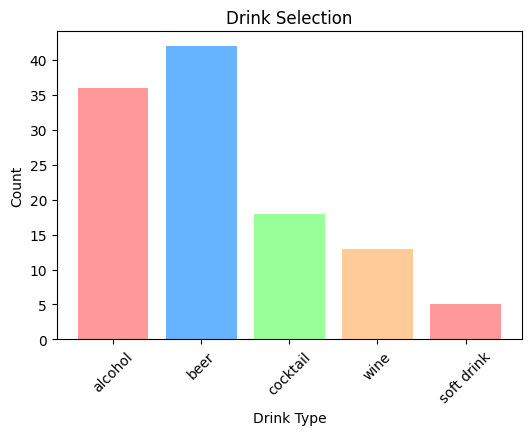

In [ ]:
# ตั้งค่าขนาดกราฟ
plt.figure(figsize=(6, 4))

# สร้าง Bar Chart
plt.bar(drink_counts.index, drink_counts.values, color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

# ตั้งชื่อกราฟ
plt.title("Drink Selection")
plt.xlabel("Drink Type")
plt.ylabel("Count")

# ตั้งค่า Label ให้ใช้จาก index ของ drink_counts
plt.xticks(rotation=45)  # ให้ Label หมุน 45 องศา

# แสดงกราฟ
plt.show()


## 2.Drinking Frequency vs. Amount of drink

### Alocohol

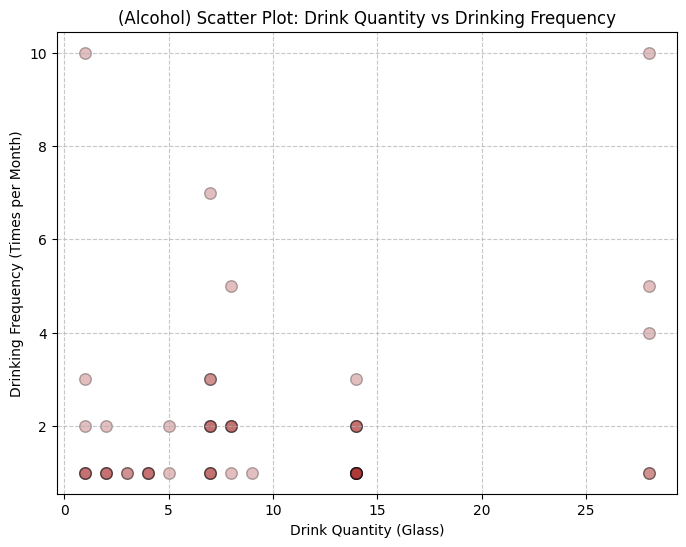

In [ ]:
# แปลงข้อมูลให้เป็นตัวเลข
df_filtered = df[df['Amount per time (Alcohol)'] != 0]
quantity_column = df_filtered['Amount per time (Alcohol)'].astype(float)
frequency_column = df_filtered['frequency per month'].astype(int)

plt.figure(figsize=(8, 6))

# สร้าง Scatter Plot
plt.scatter(quantity_column, frequency_column, alpha=0.3,color='brown', edgecolor='black', s=70)

# ตั้งค่าชื่อ
plt.title("(Alcohol) Scatter Plot: Drink Quantity vs Drinking Frequency")
plt.xlabel("Drink Quantity (Glass)")
plt.ylabel("Drinking Frequency (Times per Month)")

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



### Beer

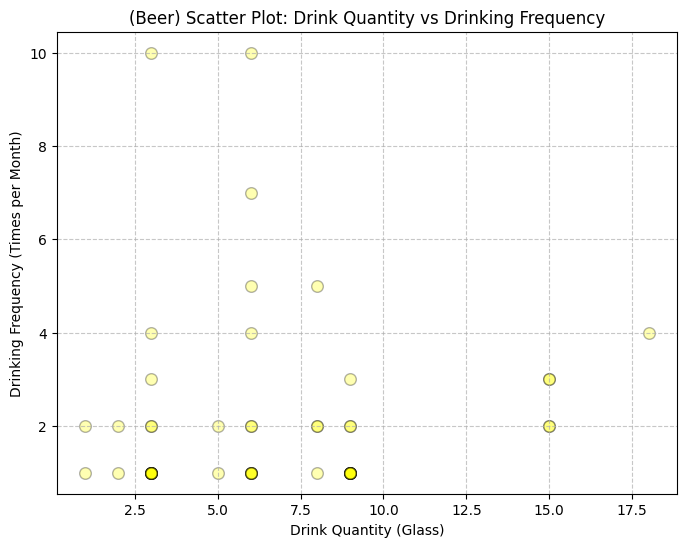

In [ ]:
# แปลงข้อมูลให้เป็นตัวเลข
df_filtered = df[df['Amount per time (Beer)'] != 0]
quantity_column = df_filtered['Amount per time (Beer)'].astype(int)
frequency_column = df_filtered['frequency per month'].astype(int)

plt.figure(figsize=(8, 6))

# สร้าง Scatter Plot
plt.scatter(quantity_column, frequency_column, alpha=0.3,color='yellow', edgecolor='black', s=70)

# ตั้งค่าชื่อ
plt.title("(Beer) Scatter Plot: Drink Quantity vs Drinking Frequency")
plt.xlabel("Drink Quantity (Glass)")
plt.ylabel("Drinking Frequency (Times per Month)")

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## 3.Relation for place and drinking time

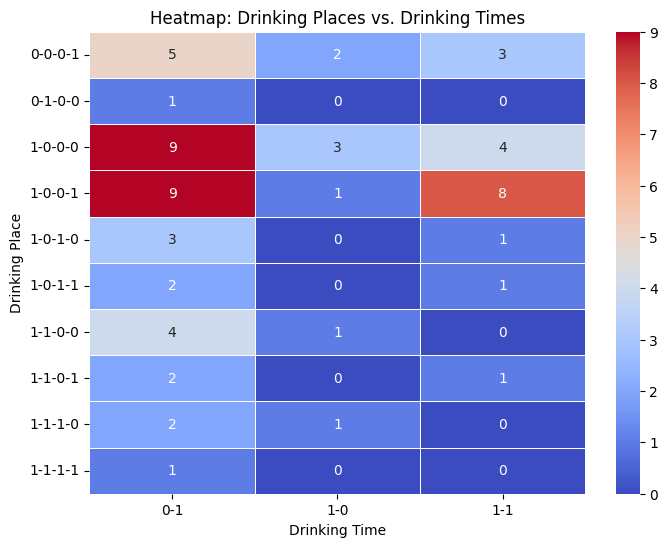

In [ ]:
# สมมติว่าคอลัมน์ที่เกี่ยวข้องมีชื่อตามนี้
place_column = "Chill-out", "Pub", "Bar", "Take-away" # (สถานที่ที่ดื่มบ่อย)

time_column = "Weekday", "Holiday" # (ช่วงเวลาที่ดื่ม)

# สร้างตาราง Pivot Table
heatmap_data = df.pivot_table(index=place_column, columns=time_column, aggfunc='size', fill_value=0)

# สร้าง Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt="d")

# ตั้งค่าชื่อแกน
plt.title("Heatmap: Drinking Places vs. Drinking Times")
plt.xlabel("Drinking Time")
plt.ylabel("Drinking Place")

plt.xticks(rotation=0)  # ทำให้แกน X อ่านง่ายขึ้น
plt.yticks(rotation=0)  # ทำให้แกน Y อ่านง่ายขึ้น

plt.show()

#### Heatmap: สถานที่ดื่ม vs. ช่วงเวลาดื่ม (Binary)

**แกน X (ช่วงเวลาดื่ม):**

* 0-1 = วันธรรมดา
* 1-0 = วันหยุด
* 1-1 = ทั้งวันธรรมดาและวันหยุด

**แกน Y (สถานที่ดื่ม):**

* 0-0-0-0 = ไม่ดื่มที่ร้านนั่งชิลล์, ผับ, บาร์, ซื้อกลับไปกินที่บ้าน/หอ
* 0-0-0-1 = ซื้อกลับไปกินที่บ้าน/หอ
* 0-0-1-0 = บาร์
* 0-0-1-1 = บาร์, ซื้อกลับไปกินที่บ้าน/หอ
* 0-1-0-0 = ผับ
* 0-1-0-1 = ผับ, ซื้อกลับไปกินที่บ้าน/หอ
* 0-1-1-0 = ผับ, บาร์
* 0-1-1-1 = ผับ, บาร์, ซื้อกลับไปกินที่บ้าน/หอ
* 1-0-0-0 = ร้านนั่งชิลล์
* 1-0-0-1 = ร้านนั่งชิลล์, ซื้อกลับไปกินที่บ้าน/หอ
* 1-0-1-0 = ร้านนั่งชิลล์, บาร์
* 1-0-1-1 = ร้านนั่งชิลล์, บาร์, ซื้อกลับไปกินที่บ้าน/หอ
* 1-1-0-0 = ร้านนั่งชิลล์, ผับ
* 1-1-0-1 = ร้านนั่งชิลล์, ผับ, ซื้อกลับไปกินที่บ้าน/หอ
* 1-1-1-0 = ร้านนั่งชิลล์, ผับ, บาร์
* 1-1-1-1 = ร้านนั่งชิลล์, ผับ, บาร์, ซื้อกลับไปกินที่บ้าน/หอ

**หมายเหตุ:**

* เลข 0 หมายถึง "ไม่ดื่ม" ที่สถานที่นั้น
* เลข 1 หมายถึง "ดื่ม" ที่สถานที่นั้น
* ลำดับของตัวเลขในแกน Y คือ ร้านนั่งชิลล์, ผับ, บาร์, ซื้อกลับไปกินที่บ้าน/หอ ตามลำดับ

## 4.Frequency drinking type ratio

In [ ]:
# คำนวณค่าเฉลี่ย
num_alcohol = df_selected['alcohol'].sum()
average_alcohol_glasses = df.iloc[:, 9].mean()

# แสดงผลค่าเฉลี่ย
print(f"จำนวนคนที่ดื่มเหล้า: {num_alcohol}")
print(f"ค่าเฉลี่ยจำนวนแก้วที่ดื่ม: {average_alcohol_glasses:.2f} แก้ว")

# คำนวณค่าเฉลี่ย
num_beer = df_selected['beer'].sum()
average_beer_glasses = df.iloc[:, 10].mean()

# แสดงผลค่าเฉลี่ย
print("-------------------------------------------------------")
print(f"จำนวนคนที่ดื่มเบียร์: {num_beer}")
print(f"ค่าเฉลี่ยจำนวนแก้วที่ดื่ม: {average_beer_glasses:.2f} แก้ว")


จำนวนคนที่ดื่มเหล้า: 36
ค่าเฉลี่ยจำนวนแก้วที่ดื่ม: 7.00 แก้ว
-------------------------------------------------------
จำนวนคนที่ดื่มเบียร์: 42
ค่าเฉลี่ยจำนวนแก้วที่ดื่ม: 5.16 แก้ว


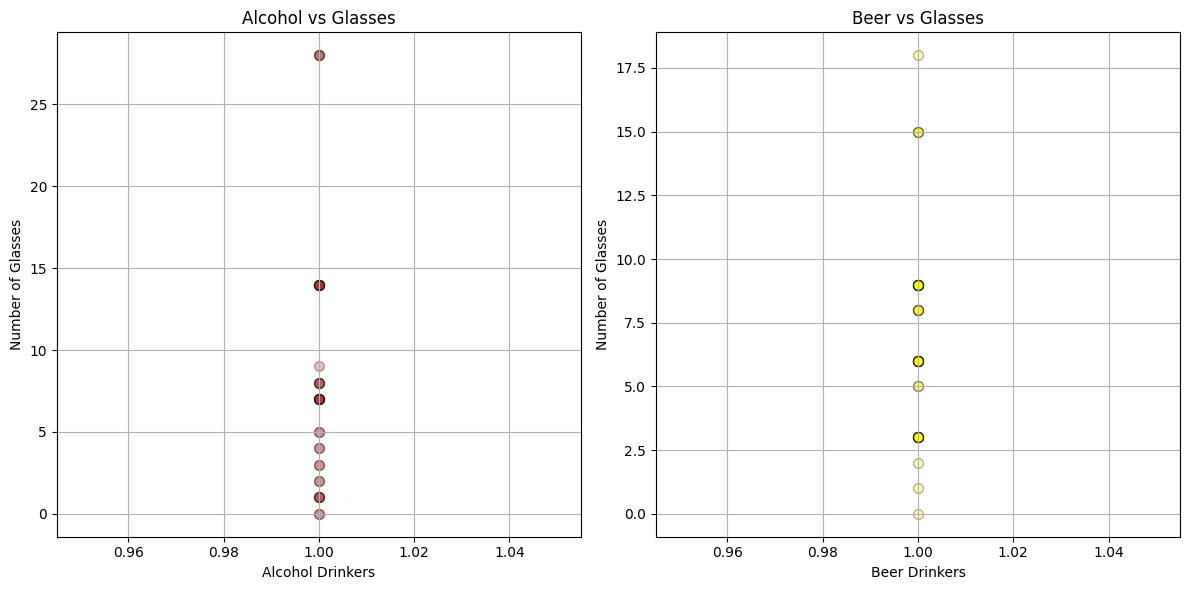

In [ ]:
# สมมติว่าข้อมูลของคุณอยู่ใน DataFrame ที่ชื่อว่า 'df_selected'
# และมีคอลัมน์ 'alcohol' และ 'beer' (จำนวนคนที่ดื่มแอลกอฮอล์และเบียร์) และ คอลัมน์ที่ 10 และ 11 (จำนวนแก้วที่ดื่มแอลกอฮอล์และเบียร์)

# Sort the y-axis values
sorted_alcohol = df.iloc[:, 9][df_selected['alcohol'] == 1].astype(float).sort_values()
sorted_beer = df.iloc[:, 10][df_selected['beer'] == 1].astype(float).sort_values()

# สร้าง Scatter Plot
plt.figure(figsize=(12, 6))  # เพิ่มขนาดกราฟเพื่อให้เห็นชัดเจน

# Scatter Plot สำหรับ Alcohol
plt.subplot(1, 2, 1)  # แบ่งกราฟเป็น 1 แถว 2 คอลัมน์, เลือก plot แรก
plt.scatter(df_selected['alcohol'][df_selected['alcohol'] == 1], sorted_alcohol, alpha=0.3,color='brown', edgecolor='black', s=50)
plt.title('Alcohol vs Glasses')
plt.xlabel('Alcohol Drinkers')
plt.ylabel('Number of Glasses')
plt.grid(True)

# Scatter Plot สำหรับ Beer
plt.subplot(1, 2, 2)  # แบ่งกราฟเป็น 1 แถว 2 คอลัมน์, เลือก plot สอง
plt.scatter(df_selected['beer'][df_selected['beer'] == 1], sorted_beer, alpha=0.3,color='yellow', edgecolor='black', s=50)
plt.title('Beer vs Glasses')
plt.xlabel('Beer Drinkers')
plt.ylabel('Number of Glasses')
plt.grid(True)

plt.tight_layout()  # ปรับ layout ของกราฟไม่ให้ทับกัน
plt.show()

## 5.Cost vs Amount of Drink

### Alocohol

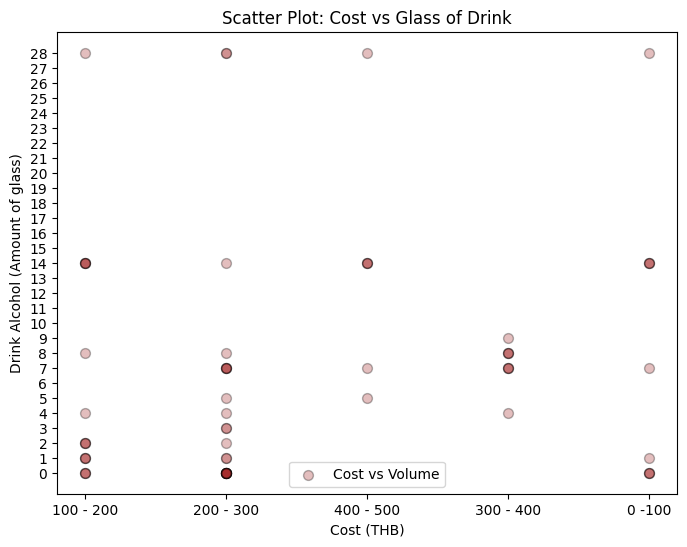

In [ ]:
x_cost = df['Cost(thb)']
y_volume = df['Amount per time (Alcohol)'].astype(float)  # แปลงเป็น float

# สร้าง Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_cost, y_volume, alpha=0.3,color='brown', edgecolor='black', s=50, label="Cost vs Volume")

# ตั้งค่า Label
plt.xlabel("Cost (THB)")
plt.ylabel("Drink Alcohol (Amount of glass)")
plt.title("Scatter Plot: Cost vs Glass of Drink")
plt.legend()

# ✅ ตั้งค่าแกน Y ให้เป็นเลขจำนวนเต็ม
plt.yticks(np.arange(min(y_volume), max(y_volume) + 1, 1))

# แสดงกราฟ
plt.show()

### Beer

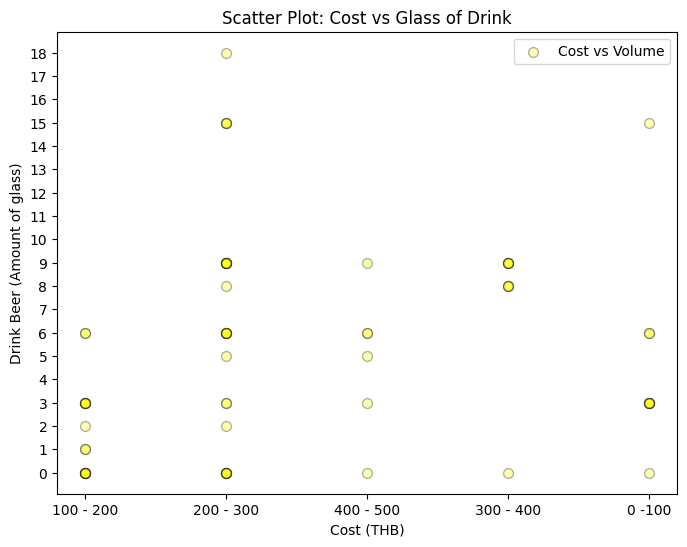

In [ ]:
# สมมติว่าข้อมูลอยู่ใน df
x_cost = df['Cost(thb)']
y_volume = df['Amount per time (Beer)'].astype(float)  # แปลงเป็น float

# สร้าง Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_cost, y_volume, alpha=0.3,color='yellow', edgecolor='black', s=50, label="Cost vs Volume")

# ตั้งค่า Label
plt.xlabel("Cost (THB)")
plt.ylabel("Drink Beer (Amount of glass)")
plt.title("Scatter Plot: Cost vs Glass of Drink")
plt.legend()

# ✅ ตั้งค่าแกน Y ให้เป็นเลขจำนวนเต็ม
plt.yticks(np.arange(min(y_volume), max(y_volume) + 1, 1))

# แสดงกราฟ
plt.show()



## 6.สัดส่วนคนที่ดื่มคนเดีนวกับเป็นกลุ่ม

In [ ]:
df.columns

Index(['Age', 'Gender', 'Faculty', 'Major', 'alcohol', 'beer', 'cocktail',
       'wine', 'soft drink', 'Amount per time (Alcohol)',
       'Amount per time (Beer)', 'frequency per month', 'Chill-out', 'Pub',
       'Bar', 'Take-away', 'Weekday', 'Holiday', 'Solo', 'Party', 'Cost(thb)'],
      dtype='object')

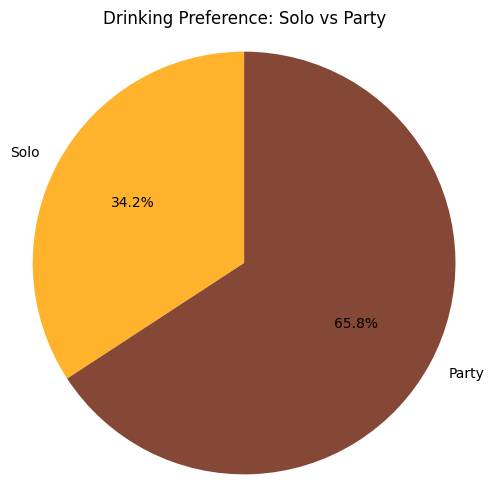

sum solo :  26
sum party :  50


In [ ]:
# Your existing calculations:
sum_solo = df.iloc[:, 18][df['Solo'] == 1].sum()
sum_party = df.iloc[:, 19][df['Party'] == 1].sum()

# Data for the pie chart
labels = ['Solo', 'Party']
sizes = [sum_solo, sum_party]
colors = ['#FFB22C', '#854836']  # Customize colors if you like

# Create the pie chart
plt.figure(figsize=(6, 6))  # Adjust figure size if needed
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Drinking Preference: Solo vs Party')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

print("sum solo : ",sum_solo)
print("sum party : ",sum_party)


# Data Processing

## Extract feature input and target label

In [ ]:
X = df.iloc[:,:-1]
y= df.iloc[:,-1]

In [ ]:
X.head()

,Age,Gender,Faculty,Major,alcohol,beer,cocktail,wine,soft drink,Amount per time (Alcohol),Amount per time (Beer),frequency per month,Chill-out,Pub,Bar,Take-away,Weekday,Holiday,Solo,Party
0,21,ชาย,คณะวิศวกรรมศาสตร์,วิศวระบบขนส่งทางราง,0,1,0,0,0,0,6,2,0,0,0,1,0,1,1,1
1,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ และฟิสิกส์อุตสาห...,1,1,0,0,0,28,6,5,1,0,0,0,1,1,1,1
2,19,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,0,0,0,0,9,1,1,0,0,0,0,1,0,1
3,22,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ,1,1,1,1,0,5,5,1,1,0,1,1,1,1,1,1
4,20,ชาย,คณะวิศวกรรมศาสตร์,ไฟฟ้าสื่อสารและอิเล็กทรอนิกส์,1,1,0,0,0,7,15,2,1,0,1,1,0,1,0,1


In [ ]:
y.head()

,Cost(thb)
0,100 - 200
1,200 - 300
2,200 - 300
3,400 - 500
4,200 - 300


## Divide the category value feature and numeric value feature

In [ ]:
category_encode_columns = ["alcohol", "beer","Chill-out", "Pub", "Bar", "Take-away", "Weekday", "Holiday","Solo","Party"]
numeric_unscaling_columns = ["Age","Amount per time (Alcohol)", "Amount per time (Beer)", "frequency per month"]
category_columns = ["Gender","Faculty","Major"]

X_category = X[category_columns]
X_unscaling_numeric = X[numeric_unscaling_columns]
X_encode_category = X[category_encode_columns]

In [ ]:
X_category.head()

,Gender,Faculty,Major
0,ชาย,คณะวิศวกรรมศาสตร์,วิศวระบบขนส่งทางราง
1,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ และฟิสิกส์อุตสาห...
2,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ
3,หญิง,คณะวิศวกรรมศาสตร์,วิศวกรรมระบบไอโอทีและสารสนเทศ
4,ชาย,คณะวิศวกรรมศาสตร์,ไฟฟ้าสื่อสารและอิเล็กทรอนิกส์


In [ ]:
X_encode_category.head()

,alcohol,beer,Chill-out,Pub,Bar,Take-away,Weekday,Holiday,Solo,Party
0,0,1,0,0,0,1,0,1,1,1
1,1,1,1,0,0,0,1,1,1,1
2,1,1,1,0,0,0,0,1,0,1
3,1,1,1,0,1,1,1,1,1,1
4,1,1,1,0,1,1,0,1,0,1


In [ ]:
X_unscaling_numeric.head()

,Age,Amount per time (Alcohol),Amount per time (Beer),frequency per month
0,21,0,6,2
1,22,28,6,5
2,19,0,9,1
3,22,5,5,1
4,20,7,15,2


## One hot encoding the category feature

In [ ]:
encoder_input = LabelEncoder()
X_category = X_category.apply(encoder_input.fit_transform)
joblib.dump(encoder_input, "label_encoder_input.pkl")
X_category.head()

,Gender,Faculty,Major
0,0,1,14
1,1,1,11
2,1,1,10
3,1,1,10
4,0,1,18


In [ ]:
X_category.shape

(64, 3)

## One hot encoding the target output

In [ ]:
encoder_output = LabelEncoder()
y = encoder_output.fit_transform(y)

In [ ]:
pd.DataFrame(y,columns=["Cost(thb)"]).head()

,Cost(thb)
0,1
1,2
2,2
3,4
4,2


In [ ]:
y.shape

(64,)

In [ ]:
encoder_output.classes_

array(['0 -100', '100 - 200', '200 - 300', '300 - 400', '400 - 500'],
      dtype=object)

In [ ]:
print(pd.Series(y).value_counts())

2    25
1    16
0     9
3     8
4     6
Name: count, dtype: int64


## Feature scaling

In [ ]:
X_unscaling_numeric.head()

,Age,Amount per time (Alcohol),Amount per time (Beer),frequency per month
0,21,0,6,2
1,22,28,6,5
2,19,0,9,1
3,22,5,5,1
4,20,7,15,2


In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_unscaling_numeric)  # Fit and transform the data

# Convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_unscaling_columns)

In [ ]:
X_scaled_df.shape

(64, 4)

In [ ]:
X_scaled_df.head()

,Age,Amount per time (Alcohol),Amount per time (Beer),frequency per month
0,0.428571,0.000000,0.333333,0.111111
1,0.571429,1.000000,0.333333,0.444444
2,0.142857,0.000000,0.500000,0.000000
3,0.571429,0.178571,0.277778,0.000000
4,0.285714,0.250000,0.833333,0.111111


## Concat the category data and numeric scaling data as Input feature

In [ ]:
X_scaled_df = X_scaled_df.reset_index(drop=True)
X_category = X_category.reset_index(drop=True)
X_encode_category = X_encode_category.reset_index(drop=True)

X_final = pd.concat([X_scaled_df, X_category, X_encode_category], axis=1)
X_final.head()

,Age,Amount per time (Alcohol),Amount per time (Beer),frequency per month,Gender,Faculty,Major,alcohol,beer,Chill-out,Pub,Bar,Take-away,Weekday,Holiday,Solo,Party
0,0.428571,0.000000,0.333333,0.111111,0,1,14,0,1,0,0,0,1,0,1,1,1
1,0.571429,1.000000,0.333333,0.444444,1,1,11,1,1,1,0,0,0,1,1,1,1
2,0.142857,0.000000,0.500000,0.000000,1,1,10,1,1,1,0,0,0,0,1,0,1
3,0.571429,0.178571,0.277778,0.000000,1,1,10,1,1,1,0,1,1,1,1,1,1
4,0.285714,0.250000,0.833333,0.111111,0,1,18,1,1,1,0,1,1,0,1,0,1


In [ ]:
X_final.shape

(64, 17)

In [ ]:
y.shape

(64,)

## Correlation

In [ ]:
look_correlation = pd.concat([X_final, pd.Series(y, name='Cost(thb)')], axis=1)
look_correlation

,Age,Amount per time (Alcohol),Amount per time (Beer),frequency per month,Gender,Faculty,Major,alcohol,beer,Chill-out,Pub,Bar,Take-away,Weekday,Holiday,Solo,Party,Cost(thb)
0,0.428571,0.000000,0.333333,0.111111,0,1,14,0,1,0,0,0,1,0,1,1,1,1
1,0.571429,1.000000,0.333333,0.444444,1,1,11,1,1,1,0,0,0,1,1,1,1,2
2,0.142857,0.000000,0.500000,0.000000,1,1,10,1,1,1,0,0,0,0,1,0,1,2
3,0.571429,0.178571,0.277778,0.000000,1,1,10,1,1,1,0,1,1,1,1,1,1,4
4,0.285714,0.250000,0.833333,0.111111,0,1,18,1,1,1,0,1,1,0,1,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.428571,0.000000,0.166667,1.000000,0,1,10,0,0,1,0,0,1,1,1,1,0,0
60,0.428571,0.000000,0.333333,0.000000,1,1,11,0,1,0,0,0,1,0,1,0,0,0
61,0.428571,0.142857,0.000000,0.000000,1,1,10,1,0,1,0,0,1,1,0,0,1,2
62,0.285714,0.035714,0.000000,1.000000,0,0,4,1,0,0,0,0,1,1,0,1,0,0


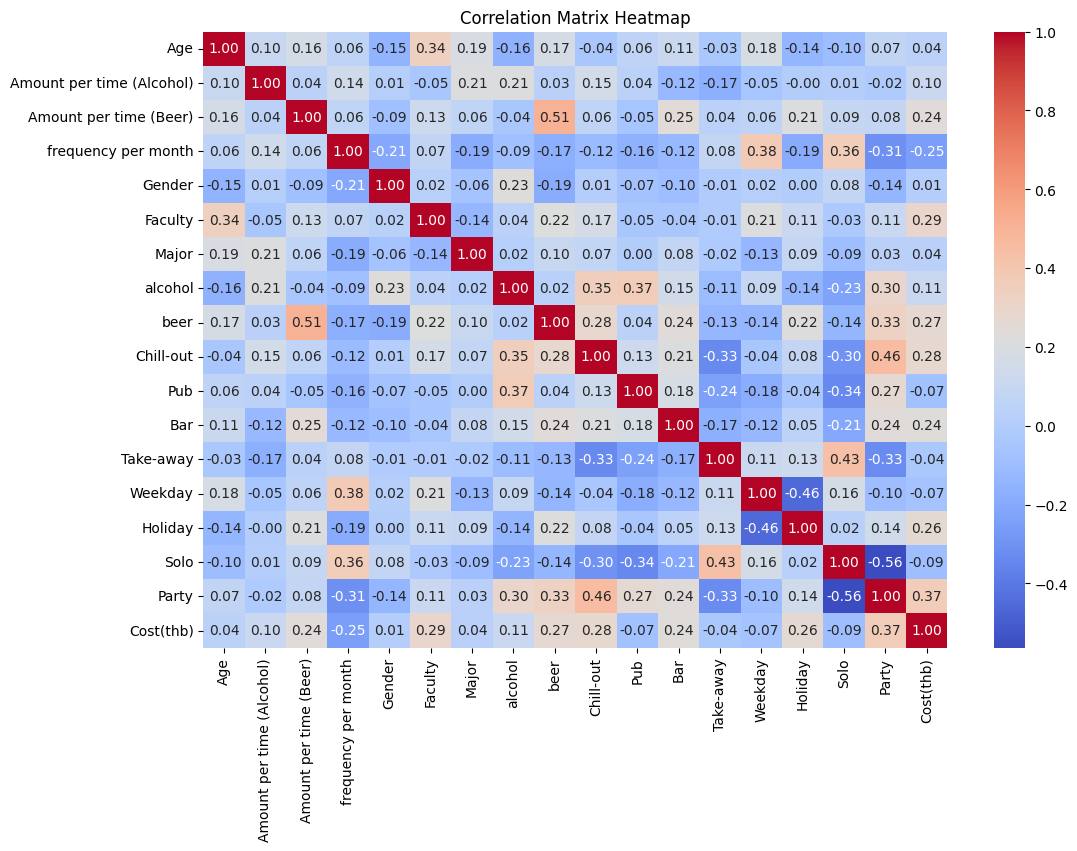

In [ ]:
correlation_matrix = look_correlation.corr(method="pearson")

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.xticks(rotation=90)
plt.show()

# Data Modeliong

## Feature selection , Parameter Selection ,Model Selection and Cross validation

## Define Model ,Feature Selection Algorithm , Hyperparameter for each model

In [ ]:
k_values = [5, 10, 15]  # Adjust as needed

feature_selectors = {}

for k in k_values:
    feature_selectors[f"SelectKBest_f_classif_k={k}"] = SelectKBest(score_func=f_classif, k=k)
    feature_selectors[f"SelectKBest_mutual_info_k={k}"] = SelectKBest(score_func=mutual_info_classif, k=k)
    feature_selectors[f"PCA_k={k}"] = PCA(n_components=k)

models = {
    "LogisticRegression": {
        "model": LogisticRegression(),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__penalty": ["l2"]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(),
        "params": {
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [5, 10, None]
        }
    },
    "SVM": {
        "model": SVC(),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"]
        }
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier(),
        "params": {
            "model__max_depth": [5, 10, 20, None],
            "model__criterion": ["gini", "entropy"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        "params": {
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [3, 6, 10],
            "model__learning_rate": [0.01, 0.1, 0.2]
        }
    }
}

## Do cross validation through the define parameter

In [ ]:
results = []

# Loop over feature selection methods
for selector_name, selector in feature_selectors.items():
    print(f"\n🔹 Testing Feature Selection: {selector_name}")

    # Loop over models
    for model_name, model_info in models.items():
        print(f"  ▶️ Training Model: {model_name}")

        # Create pipeline with feature selection, and model
        pipeline = Pipeline([
            ("selector", selector),
            ("model", model_info["model"])
        ])

        # Perform Grid Search with Cross-Validation
        grid = GridSearchCV(pipeline, param_grid=model_info["params"], cv=5, scoring="accuracy")
        grid.fit(X_final, y)

        # Evaluate using cross-validation
        best_model = grid.best_estimator_
        scores = cross_val_score(best_model, X_final, y, cv=5, scoring="accuracy")

        # Store results
        results.append({
            "Feature Selection": selector_name,
            "Model": model_name,
            "Best Params": grid.best_params_,
            "Mean Accuracy": np.mean(scores),
            "All Scores": scores
        })


🔹 Testing Feature Selection: SelectKBest_f_classif_k=5
  ▶️ Training Model: LogisticRegression
  ▶️ Training Model: RandomForest
  ▶️ Training Model: SVM
  ▶️ Training Model: DecisionTree
  ▶️ Training Model: XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:26:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:26:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:26:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:26:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:26:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


🔹 Testing Feature Selection: SelectKBest_mutual_info_k=5
  ▶️ Training Model: LogisticRegression
  ▶️ Training Model: RandomForest
  ▶️ Training Model: SVM
  ▶️ Training Model: DecisionTree
  ▶️ Training Model: XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:27:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:27:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:27:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:27:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:27:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


🔹 Testing Feature Selection: PCA_k=5
  ▶️ Training Model: LogisticRegression
  ▶️ Training Model: RandomForest
  ▶️ Training Model: SVM
  ▶️ Training Model: DecisionTree
  ▶️ Training Model: XGBoost


...

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  ▶️ Training Model: RandomForest
  ▶️ Training Model: SVM
  ▶️ Training Model: DecisionTree
  ▶️ Training Model: XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:31:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:31:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:31:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:31:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:31:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


🔹 Testing Feature Selection: PCA_k=15
  ▶️ Training Model: LogisticRegression
  ▶️ Training Model: RandomForest
  ▶️ Training Model: SVM
  ▶️ Training Model: DecisionTree
  ▶️ Training Model: XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:32:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:32:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:32:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:32:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:32:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

## Result of each model cross validation

In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Rename columns for better readability
results_df = results_df.rename(columns={
    "Feature Selection": "Feature Selection Method",
    "Model": "Model Name",
    "Best Params": "Best Hyperparameters",
    "Mean Accuracy": "Mean Accuracy (CV)",
    "All Scores": "CV Scores"
})

# Sort results by Mean Accuracy (highest first)
results_df = results_df.sort_values(by="Mean Accuracy (CV)", ascending=False)

# Display as a formatted DataFrame
from IPython.display import display  # Use in Jupyter Notebook

print("\n✅ Final Results:")
display(results_df)  # Use display() for Jupyter Notebook


✅ Final Results:


,Feature Selection Method,Model Name,Best Hyperparameters,Mean Accuracy (CV),CV Scores
19,SelectKBest_f_classif_k=10,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.564103,"[0.38461538461538464, 0.6153846153846154, 0.61..."
34,SelectKBest_f_classif_k=15,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.548718,"[0.38461538461538464, 0.6923076923076923, 0.53..."
5,SelectKBest_mutual_info_k=5,LogisticRegression,"{'model__C': 10, 'model__penalty': 'l2'}",0.547436,"[0.38461538461538464, 0.6153846153846154, 0.53..."
24,SelectKBest_mutual_info_k=10,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.532051,"[0.46153846153846156, 0.6153846153846154, 0.53..."
0,SelectKBest_f_classif_k=5,LogisticRegression,"{'model__C': 10, 'model__penalty': 'l2'}",0.532051,"[0.23076923076923078, 0.6153846153846154, 0.53..."
22,SelectKBest_mutual_info_k=10,SVM,"{'model__C': 1, 'model__kernel': 'linear'}",0.530769,"[0.38461538461538464, 0.6923076923076923, 0.38..."
20,SelectKBest_mutual_info_k=10,LogisticRegression,"{'model__C': 1, 'model__penalty': 'l2'}",0.530769,"[0.46153846153846156, 0.5384615384615384, 0.38..."
4,SelectKBest_f_classif_k=5,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.516667,"[0.38461538461538464, 0.6153846153846154, 0.53..."
42,PCA_k=15,SVM,"{'model__C': 1, 'model__kernel': 'linear'}",0.515385,"[0.38461538461538464, 0.6153846153846154, 0.46..."
17,SelectKBest_f_classif_k=10,SVM,"{'model__C': 1, 'model__kernel': 'linear'}",0.515385,"[0.38461538461538464, 0.5384615384615384, 0.46..."


## Select the best model that contain the best hyperparameter and the best feature selection algorithm

In [ ]:
k = 10  # Adjust as needed
feature_selection = SelectKBest(score_func=mutual_info_classif, k=k)
X_feature_selection = feature_selection.fit_transform(X_final, y)
X_train, X_test, y_train, y_test = train_test_split(X_feature_selection, y, test_size=0.1,random_state=42)

model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss',learning_rate=0.01, max_depth=3, n_estimators=50)

In [ ]:
pd.DataFrame(X_feature_selection).head()

,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.333333,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
1,1.000000,0.333333,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
2,0.000000,0.500000,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
3,0.178571,0.277778,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,0.250000,0.833333,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0


## Train model

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:32:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

#Model evaluation

In [ ]:
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy after PCA: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy after PCA: 0.4286
Precision: 0.6429
Recall: 0.4286
F1 Score: 0.4592


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Classification Report

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.33      0.50         3
           2       0.50      0.67      0.57         3
           4       0.00      0.00      0.00         0

    accuracy                           0.43         7
   macro avg       0.38      0.25      0.27         7
weighted avg       0.64      0.43      0.46         7



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
df.groupby("Cost(thb)")["Cost(thb)"].count()

,Cost(thb)
Cost(thb),
0 -100,9
100 - 200,16
200 - 300,25
300 - 400,8
400 - 500,6
